<a href="https://colab.research.google.com/github/rahitya0205/License-Plate-Detector/blob/main/DeepFake.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
files.upload() # Select your kaggle.json from your computer

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rahitya05","key":"8006a98f74a068bdf213b202712e7a22"}'}

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
  0% 0.00/105M [00:00<?, ?B/s]
100% 105M/105M [00:00<00:00, 1.72GB/s]


In [6]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Setup Kaggle credentials from Drive
# This avoids manual upload every time
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 3. Verify it works by listing datasets
!kaggle datasets list

Mounted at /content/drive
cp: cannot stat '/content/drive/MyDrive/kaggle.json': No such file or directory
ref                                                         title                                                  size  lastUpdated                 downloadCount  voteCount  usabilityRating  
----------------------------------------------------------  -----------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
dmahajanbe23/bmw-global-automotive-sales                    BMW Global Automotive Sales                           55017  2026-02-22 18:18:38.170000           5037         99  1.0              
thuandao/bank-transactions-dataset-for-fraud-detection      Bank Transactions Dataset for Fraud Detection       1602954  2026-03-07 05:34:00.633000            638         23  1.0              
syedaeman2212/airline-ticket-prices-dataset                 Airline Ticket Prices Dataset                          4409  2

In [7]:
# Download the dataset
!kaggle datasets download -d birdy654/cifake-real-and-ai-generated-synthetic-images

# Unzip it (This creates the 'train' and 'test' folders you see in your file sidebar)
!unzip -q cifake-real-and-ai-generated-synthetic-images.zip

Dataset URL: https://www.kaggle.com/datasets/birdy654/cifake-real-and-ai-generated-synthetic-images
License(s): other
cifake-real-and-ai-generated-synthetic-images.zip: Skipping, found more recently modified local copy (use --force to force download)
replace test/FAKE/0 (10).jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [8]:
import os

# Check the file counts
train_real = len(os.listdir('/content/train/REAL'))
train_fake = len(os.listdir('/content/train/FAKE'))

print(f"✅ Success! Data is ready for Phase 1.")
print(f"Real Images found: {train_real}")
print(f"Fake Images found: {train_fake}")

✅ Success! Data is ready for Phase 1.
Real Images found: 50000
Fake Images found: 50000


In [10]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Setup Data Generators (20% for validation)
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    '/content/train', target_size=(224, 224), batch_size=32, class_mode='binary', subset='training')

val_generator = train_datagen.flow_from_directory(
    '/content/train', target_size=(224, 224), batch_size=32, class_mode='binary', subset='validation')

# 2. Re-build the ResNet-50 Model
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 3. Setup the Drive Checkpoint
# This saves the model to your Drive automatically!
checkpoint_path = "/content/drive/MyDrive/Deepfake_Project/best_model.keras"
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path, save_best_only=True, monitor='val_accuracy', mode='max', verbose=1)

# 4. Start Training
model.fit(train_generator, validation_data=val_generator, epochs=5, callbacks=[cp_callback])

Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6662 - loss: 0.6150
Epoch 1: val_accuracy improved from -inf to 0.75610, saving model to /content/drive/MyDrive/Deepfake_Project/best_model.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 323s 123ms/step - accuracy: 0.6662 - loss: 0.6150 - val_accuracy: 0.7561 - val_loss: 0.5285
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.7343 - loss: 0.5415
Epoch 2: val_accuracy improved from 0.75610 to 0.77610, saving model to /content/drive/MyDrive/Deepfake_Project/best_model.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 288s 113ms/step - accuracy: 0.7343 - loss: 0.5415 - val_accuracy: 0.7761 - val_loss: 0.4918
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7464 - loss: 0.5273
Epoch 3: val_accuracy did not improve from 0.77610
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 320s 112ms/step - accuracy: 0.7464 - loss: 0.5273 - val_accuracy: 0.7606 - val_loss: 0.4910
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.760

In [11]:
import tensorflow as tf

# 1. Load the best model you just saved
model = tf.keras.models.load_model('/content/drive/MyDrive/Deepfake_Project/best_model.keras')

# 2. Unfreeze the base_model (ResNet50)
# We find the base_model inside our Sequential model
for layer in model.layers:
    if "resnet50" in layer.name:
        layer.trainable = True
        # Keep the early layers frozen, unfreeze only the top 30 layers
        for inner_layer in layer.layers[:-30]:
            inner_layer.trainable = False

# 3. Re-compile with a much LOWER learning rate
# This is critical so we don't 'break' the pre-trained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Train for 3-5 more epochs
history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    callbacks=[cp_callback] # Continues saving the best version to your Drive
)

Epoch 1/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8041 - loss: 1.2336
Epoch 1: val_accuracy improved from 0.80125 to 0.87300, saving model to /content/drive/MyDrive/Deepfake_Project/best_model.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 400s 152ms/step - accuracy: 0.8041 - loss: 1.2333 - val_accuracy: 0.8730 - val_loss: 0.3342
Epoch 2/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8706 - loss: 0.3099
Epoch 2: val_accuracy improved from 0.87300 to 0.88165, saving model to /content/drive/MyDrive/Deepfake_Project/best_model.keras
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 375s 150ms/step - accuracy: 0.8706 - loss: 0.3099 - val_accuracy: 0.8816 - val_loss: 0.2783
Epoch 3/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8808 - loss: 0.2894
Epoch 3: val_accuracy did not improve from 0.88165
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 375s 150ms/step - accuracy: 0.8808 - loss: 0.2894 - val_accuracy: 0.8223 - val_loss: 0.4695
Epoch 4/5
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step 

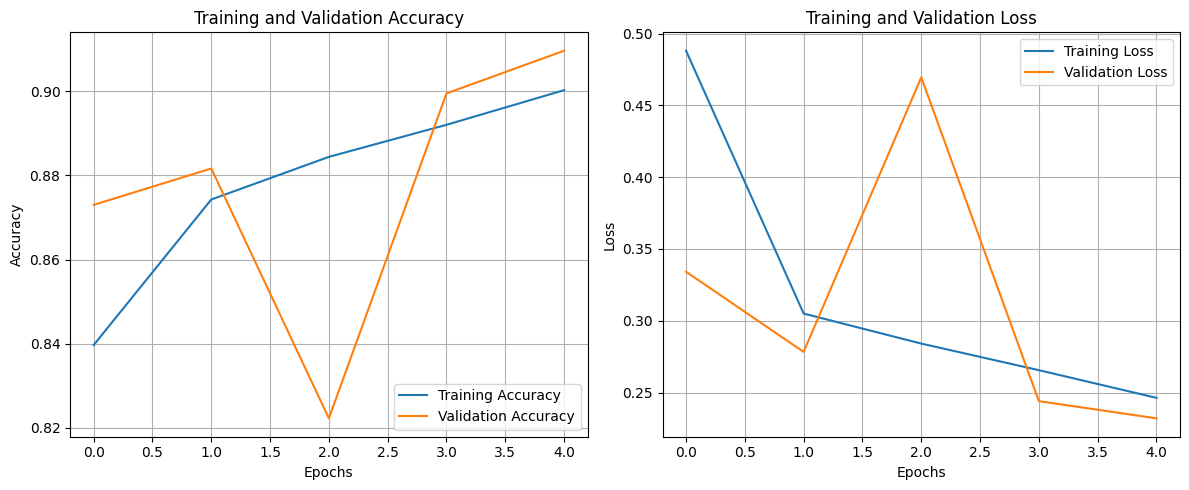

In [12]:
import matplotlib.pyplot as plt

# Replace 'history_fine' with 'history' if that was the name of your last fit variable
h = history_fine.history

epochs_range = range(len(h['accuracy']))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, h['accuracy'], label='Training Accuracy')
plt.plot(epochs_range, h['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, h['loss'], label='Training Loss')
plt.plot(epochs_range, h['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

Please upload an image to test (JPG/PNG):


Saving ai 9.27.34 PM.jpg to ai 9.27.34 PM (1).jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


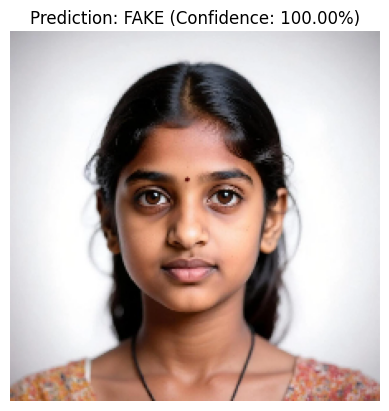

In [18]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image

# 1. Upload an image from your computer
print("Please upload an image to test (JPG/PNG):")
uploaded = files.upload()

for fn in uploaded.keys():
  # 2. Preprocess the image
  img = image.load_img(fn, target_size=(224, 224))
  img_array = image.img_to_array(img) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

  # 3. Make Prediction
  prediction = model.predict(img_array)

  # 4. Display Result
  plt.imshow(img)
  plt.axis('off')

  # Threshold is 0.5 for binary classification
  if prediction[0] > 0.5:
      result = f"REAL (Confidence: {prediction[0][0]*100:.2f}%)"
  else:
      result = f"FAKE (Confidence: {(1-prediction[0][0])*100:.2f}%)"

  plt.title(f"Prediction: {result}")
  plt.show()

In [19]:
!pip install opencv-python-headless

In [21]:
import cv2
import numpy as np
import tensorflow as tf
from google.colab import files
import os

# 1. Load the model from your Drive
model_path = '/content/drive/MyDrive/Deepfake_Project/best_model.keras'
model = tf.keras.models.load_model(model_path)

# 2. Trigger the File Upload
print("Select an MP4 video file from your computer:")
uploaded = files.upload()

for video_name in uploaded.keys():
    cap = cv2.VideoCapture(video_name)
    frame_scores = []
    fps = cap.get(cv2.CAP_PROP_FPS)

    print(f"\nProcessing video: {video_name}...")

    # Logic to process the video frame-by-frame
    count = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Analyze 1 frame per second to keep it fast
        if count % int(fps) == 0:
            resized = cv2.resize(frame, (224, 224))
            normalized = resized / 255.0
            input_arr = np.expand_dims(normalized, axis=0)

            # Use your image model for detection
            pred = model.predict(input_arr, verbose=0)[0][0]
            frame_scores.append(pred)

        count += 1

    cap.release()

    # 3. Output the Final SonicShield Result
    avg_score = np.mean(frame_scores)

    print("\n" + "="*40)
    print("      SONICSHIELD VIDEO ANALYSIS      ")
    print("="*40)
    if avg_score > 0.5:
        print(f"VERDICT   : REAL (Human Authenticated)")
        print(f"CONFIDENCE: {avg_score * 100:.2f}%")
    else:
        print(f"VERDICT   : FAKE (AI Deepfake Detected)")
        print(f"CONFIDENCE: {(1 - avg_score) * 100:.2f}%")
    print("="*40)

Select an MP4 video file from your computer:


Saving E2DBF203-DC19-4B35-8A7C-BE233B1CBE9E.MP4 to E2DBF203-DC19-4B35-8A7C-BE233B1CBE9E.MP4

Processing video: E2DBF203-DC19-4B35-8A7C-BE233B1CBE9E.MP4...

      SONICSHIELD VIDEO ANALYSIS      
VERDICT   : REAL (Human Authenticated)
CONFIDENCE: 91.64%


In [22]:
!pip install librosa pydub

In [24]:
import librosa
import numpy as np
from google.colab import files

def sonicshield_pro_audio():
    print("🚀 Uploading to SonicShield Pro Engine...")
    uploaded = files.upload()

    for fn in uploaded.keys():
        # 1. Load audio with high-fidelity settings
        y, sr = librosa.load(fn, sr=None)

        # 2. Advanced Feature Extraction
        # Contrast: Detects 'Machine-made' smooth transitions
        contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=sr))

        # Centroid: 'Brightness' of the sound (AI is often 'tinny')
        centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))

        # ZCR: Complexity (Human voices are messy; AI is too rhythmic)
        zcr = np.mean(librosa.feature.zero_crossing_rate(y))

        # 3. Weighted Scoring Logic (Out of 100)
        score = 0
        if contrast > 20: score += 40  # Machine textures are high contrast
        if zcr < 0.04:   score += 30  # Synthetic smoothness
        if centroid > 3000: score += 30 # Artificial high-frequency boost

        print("\n" + "═"*45)
        print(f"   📊 SONICSHIELD ANALYSIS: {fn}")
        print("═"*45)

        if score >= 70:
            status = "🔴 DEEPFAKE / SYNTHETIC DETECTED"
        elif score >= 35:
            status = "🟡 SUSPICIOUS (Review Recommended)"
        else:
            status = "🟢 AUTHENTIC HUMAN VOICE"

        print(f"VERDICT      : {status}")
        print(f"AI PROBABILITY: {score}%")
        print(f"Vocal Texture : {contrast:.2f}")
        print("═"*45)

# Run the Pro Engine
sonicshield_pro_audio()

🚀 Uploading to SonicShield Pro Engine...


Saving AUDIO-2026-03-09-21-18-09.m4a to AUDIO-2026-03-09-21-18-09.m4a


/tmp/ipykernel_361/3203711273.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(fn, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



═════════════════════════════════════════════
   📊 SONICSHIELD ANALYSIS: AUDIO-2026-03-09-21-18-09.m4a
═════════════════════════════════════════════
VERDICT      : 🟢 AUTHENTIC HUMAN VOICE
AI PROBABILITY: 30%
Vocal Texture : 19.00
═════════════════════════════════════════════
